In [9]:
import os
import glob
import rasterio
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
from plotting import plot_spectra


In [10]:
indir = r"C:\DDrive\Vega\Proba-reprocessing\Outputs\ReflectanceProducts"
site = "Hyytiala"
#site = "Montreal"
searchstr = os.path.join(indir,site,"*.tif")
files = glob.glob(searchstr)
if len(files) == 0:
    raise SystemExit("Could not find files in {}".format(searchstr))
else:
    file = files[0]

In [11]:
ds = rasterio.open(file)
img = ds.read().astype(np.float32)
print("Dataset: {}".format(img.shape))
nbands = img.shape[0]
ds.close()
print("Read in data: {} {}".format(np.nanmin(img),np.nanmax(img)))

Dataset: (62, 374, 372)
Read in data: 1.401298464324817e-45 2.870452404022217


Plot written to: MESSR-spectra.png


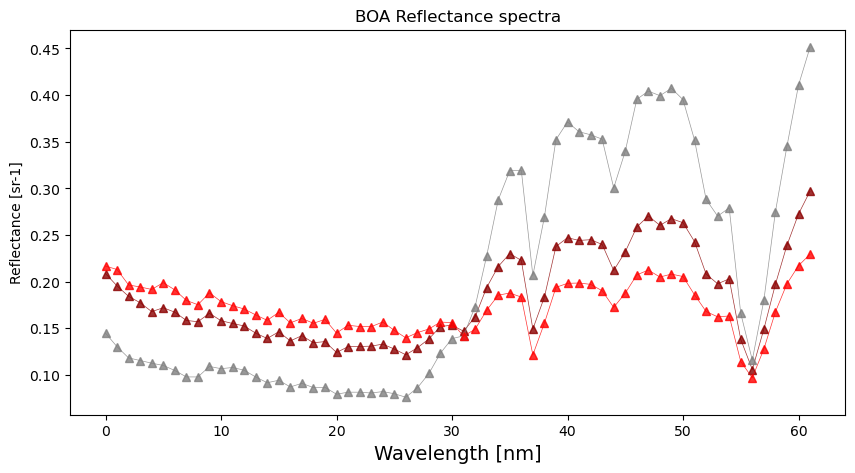

In [12]:
pbands = np.arange(0,nbands,1)
pixels = [0,350,700]
if img.shape[1] < 700:
    pixels = [0,150,350]
title = "BOA Reflectance spectra" 
plot_spectra(pbands, None, img, pixels, title)